<a href="https://colab.research.google.com/github/NaoKB/EML/blob/main/k_brazos/bandit_experiment.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Estudio comparativo de algoritmos en un problema de k-armed bandit

*Description:* El experimento compara el rendimiento de algoritmos epsilon-greedy en un problema de k-armed bandit.
Se generan gráficas de recompensas promedio para cada algoritmo.

    Author: Luis Daniel Hernández Molinero y modificado por el alumno Joaquín Ayala Filardi
    Email: ldaniel@um.es
    Date: 2025/01/29

This software is licensed under the GNU General Public License v3.0 (GPL-3.0),
with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html



## Preparación del entorno


In [19]:
!git clone https://github.com/NaoKB/EML.git
!cd EML/

fatal: destination path 'EML' already exists and is not an empty directory.


In [20]:
import sys
sys.path.append('/content/eml_k_bandit')

import numpy as np
from typing import List
import copy
from k_brazos.src.algorithms import Algorithm, EpsilonGreedy
from k_brazos.src.arms import ArmNormal, ArmBinomial, ArmBernoulli, Bandit
from k_brazos.src.plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret

SEED = 42
np.random.seed(SEED)

## Experimento

Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos en términos de recompensa promedio.

Por ejemplo. Dado un bandido de k-brazos, se ejecutan dos algoritmos epsilon-greedy con diferentes valores de epsilon. Se estudia la evolución de cada política  en un número de pasos, por ejemplo, mil pasos. Entonces se repite el experimento un número de veces, por ejemplo, 500 veces. Es decir, se ejecutan 500 veces la evolución de cada algoritmo en 1000 pasos. Para cada paso calculamos el promedio de las recoponensas obtenidas en esas 500 veces.

In [21]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):
    optimal_arm = bandit.optimal_arm
    rewards = np.zeros((len(algorithms), steps))
    optimal_selections = np.zeros((len(algorithms), steps))

    total_rewards = np.zeros((len(algorithms), steps))
    q = bandit.get_expected_value(optimal_arm)
    rewards_per_arm = np.zeros((len(algorithms), bandit.k))
    counts_per_arm  = np.zeros((len(algorithms), bandit.k))

    for _ in range(runs):
        current_bandit = Bandit(arms=bandit.arms)
        [algo.reset() for algo in algorithms]
        total_rewards_per_algo = np.zeros(len(algorithms))

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm()
                reward = current_bandit.pull_arm(chosen_arm)
                algo.update(chosen_arm, reward)
                rewards[idx, step] += reward
                rewards_per_arm[idx, chosen_arm] += reward
                counts_per_arm[idx, chosen_arm] += 1
                optimal_selections[idx, step] += {True: 1, False: 0}[chosen_arm == optimal_arm]
                total_rewards_per_algo[idx] += q - reward
                total_rewards[idx, step] += total_rewards_per_algo[idx]

    rewards /= runs
    optimal_selections /= runs
    total_rewards /= runs
    rewards_per_arm /= runs
    counts_per_arm  /= runs 

    return rewards, optimal_selections, total_rewards, rewards_per_arm, counts_per_arm

## Ejecución del experimento

Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución gaussina con desviación 1. Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan 3 algoritmos epsilon greedy para valores epsilon: 0.0, 0.01, y 0.1.

In [22]:
k = 10; steps = 1000; runs = 500; n = 10
NORMAL_NAME = "normal" ; BERNOULLI_NAME = "bernoulli" ; BINOMIAL_NAME = "binomial"
REWARDS_NAME = "rewards" ; OPTIMAL_NAME = "optimal" ; REGRET_NAME = "regret"
COUNTS_NAME = "counts" ; VALUES_NAME = "values"
algorithms = [EpsilonGreedy(k=k, epsilon=epsilon) for epsilon in [0, 0.01, 0.1]]

bandits = {
    NORMAL_NAME: Bandit(arms=ArmNormal.generate_arms(k)),
    BERNOULLI_NAME: Bandit(arms=ArmBernoulli.generate_arms(k)),
    BINOMIAL_NAME: Bandit(arms=ArmBinomial.generate_arms(k, n=n))
}

metric_names = [REWARDS_NAME, OPTIMAL_NAME, REGRET_NAME, COUNTS_NAME, VALUES_NAME]
results = {
    name: dict(zip(metric_names, run_experiment(bandit, algorithms, steps, runs)))
    for name, bandit in bandits.items()
}

In [23]:
def plot(function, steps, results, results_key, algorithms, title):
    for name, result in results.items():
        function(steps, result[results_key], algorithms, f"{title} - {name}")

## Visualización de los resultados

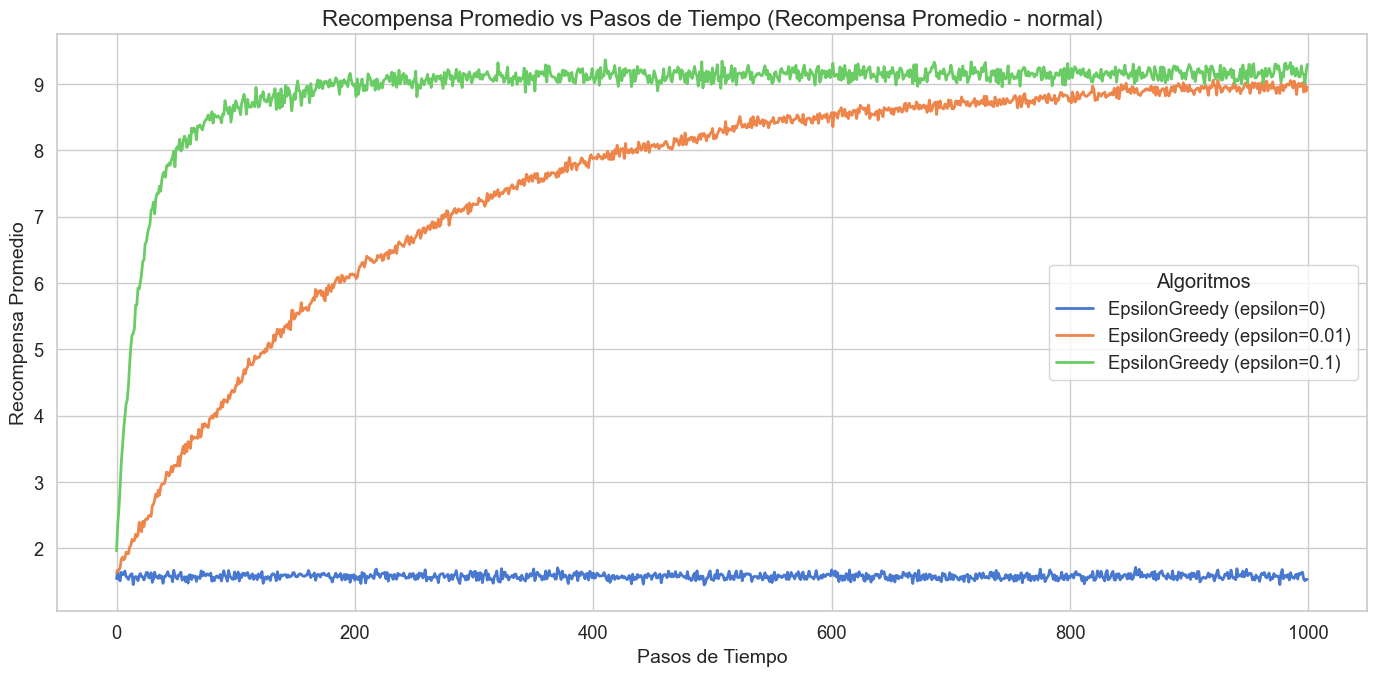

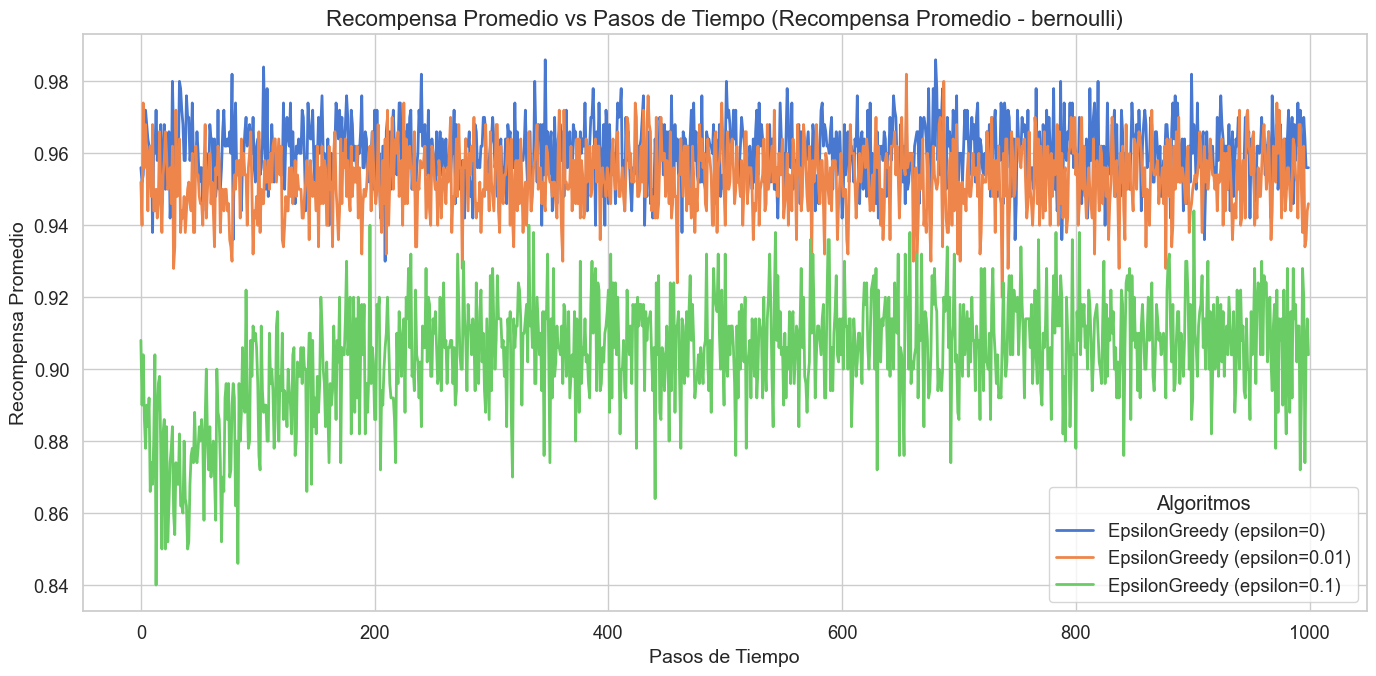

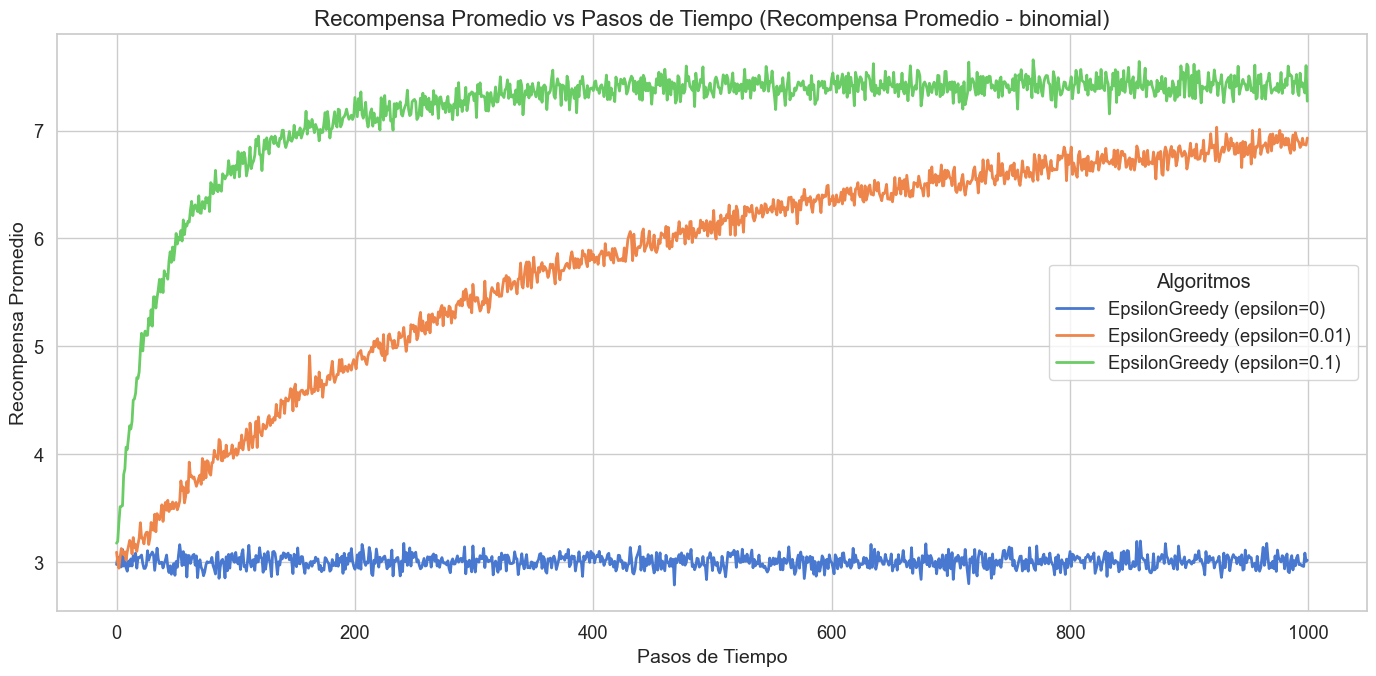

In [24]:
plot(plot_average_rewards, steps, results, REWARDS_NAME, algorithms, "Recompensa Promedio")

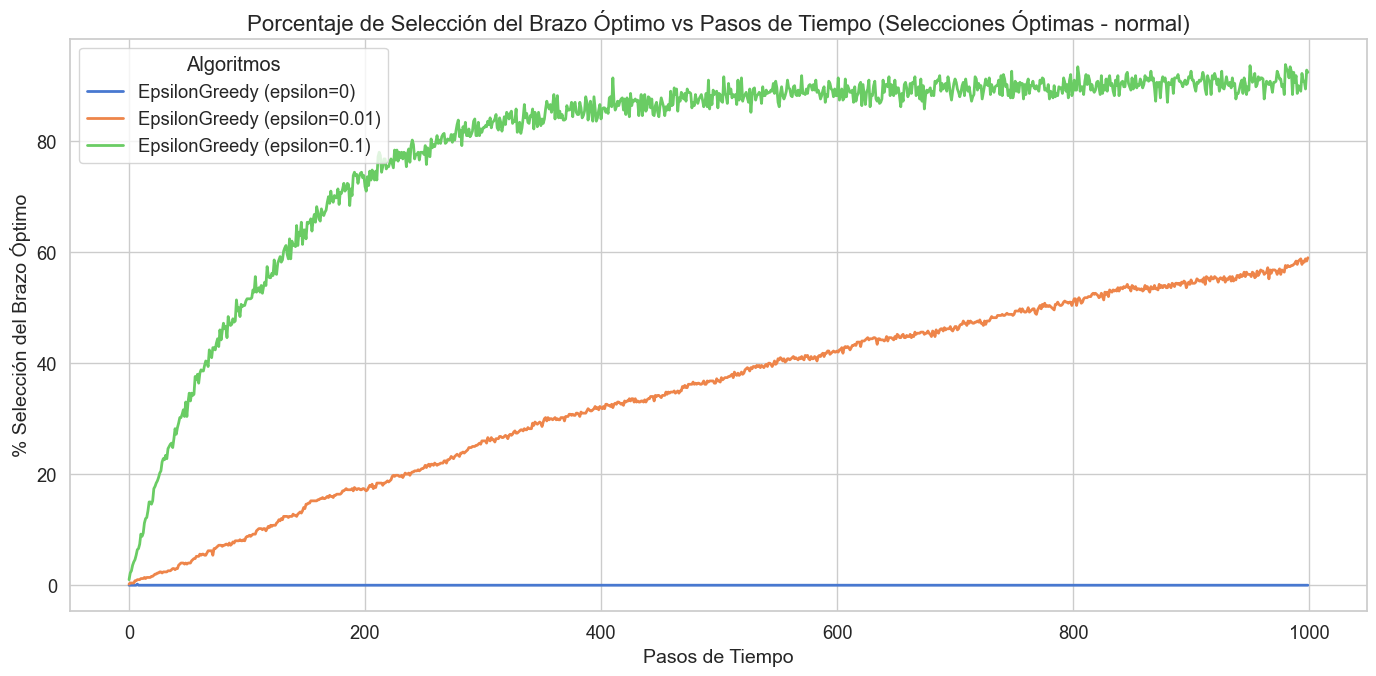

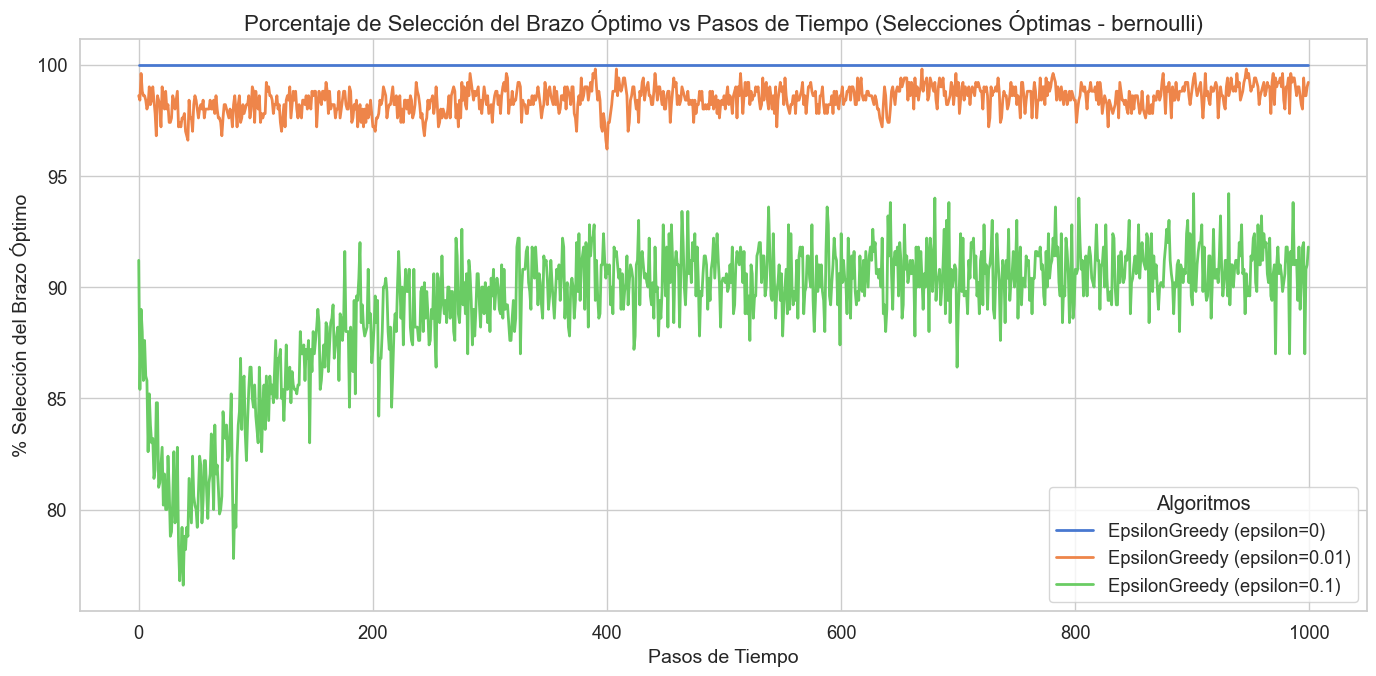

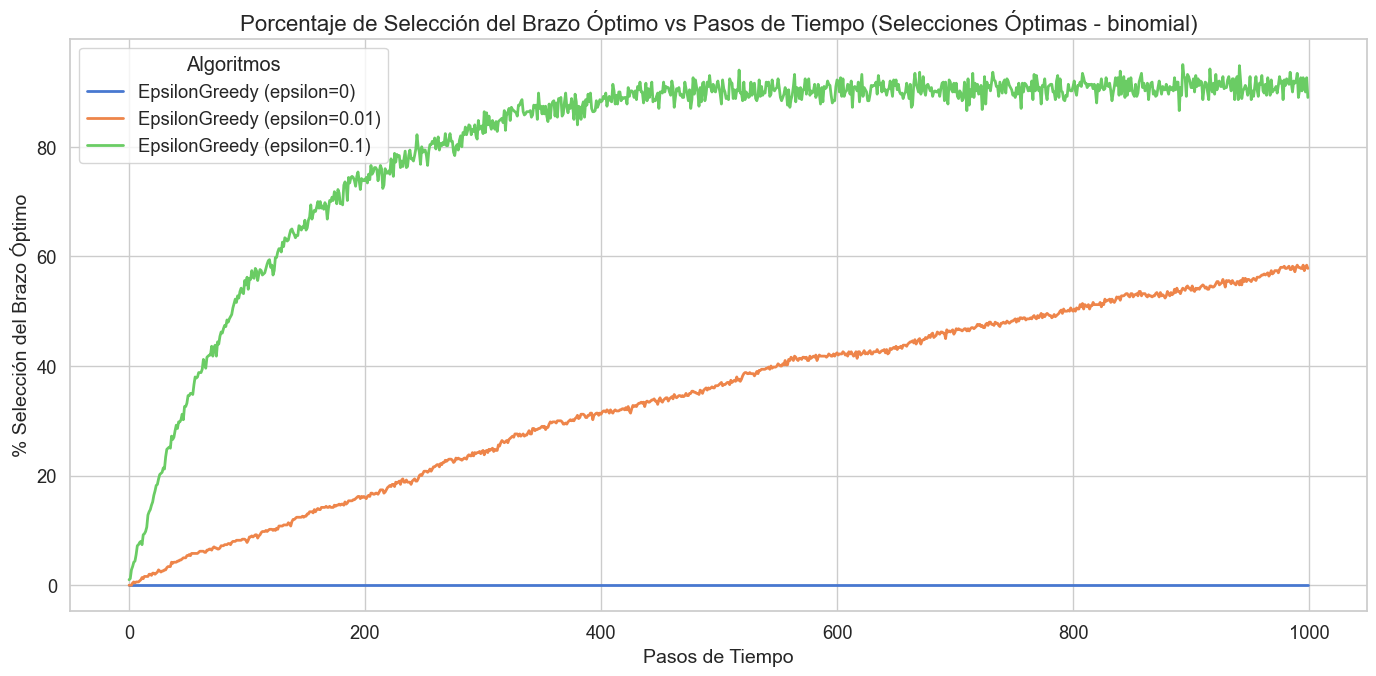

In [25]:
plot(plot_optimal_selections, steps, results, OPTIMAL_NAME, algorithms, "Selecciones Óptimas")

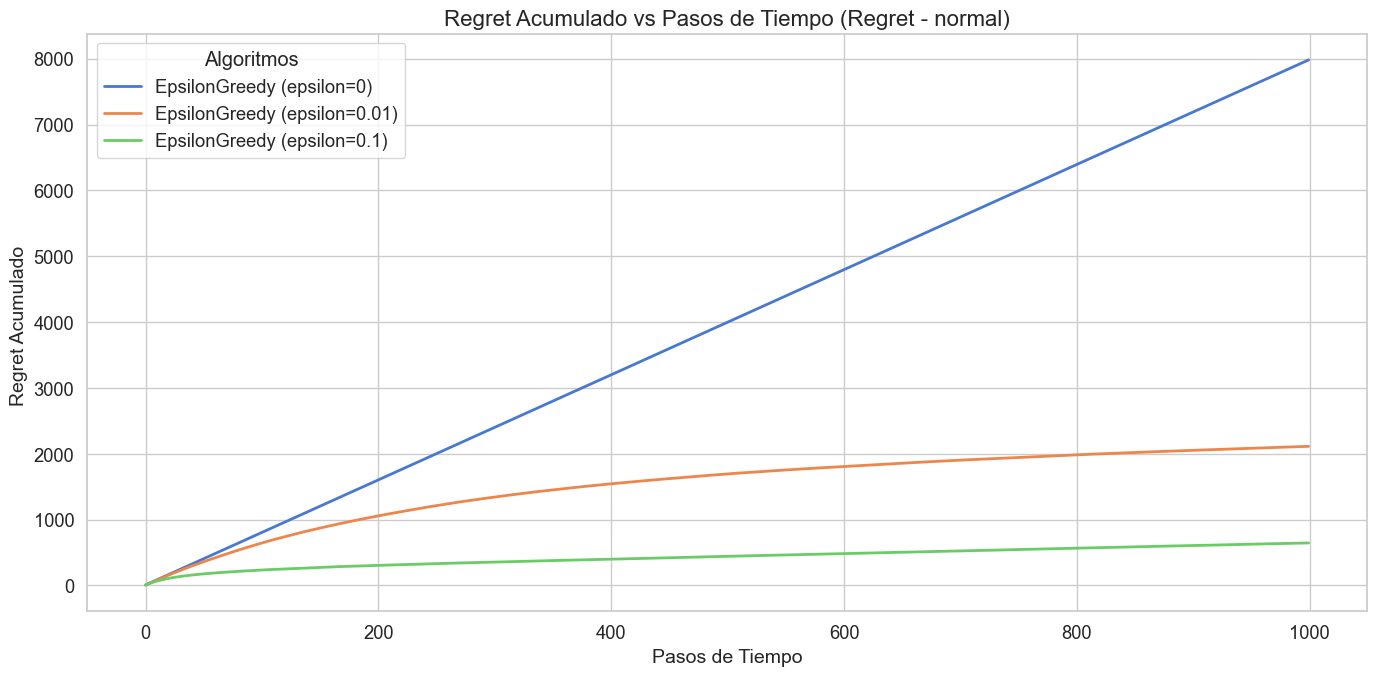

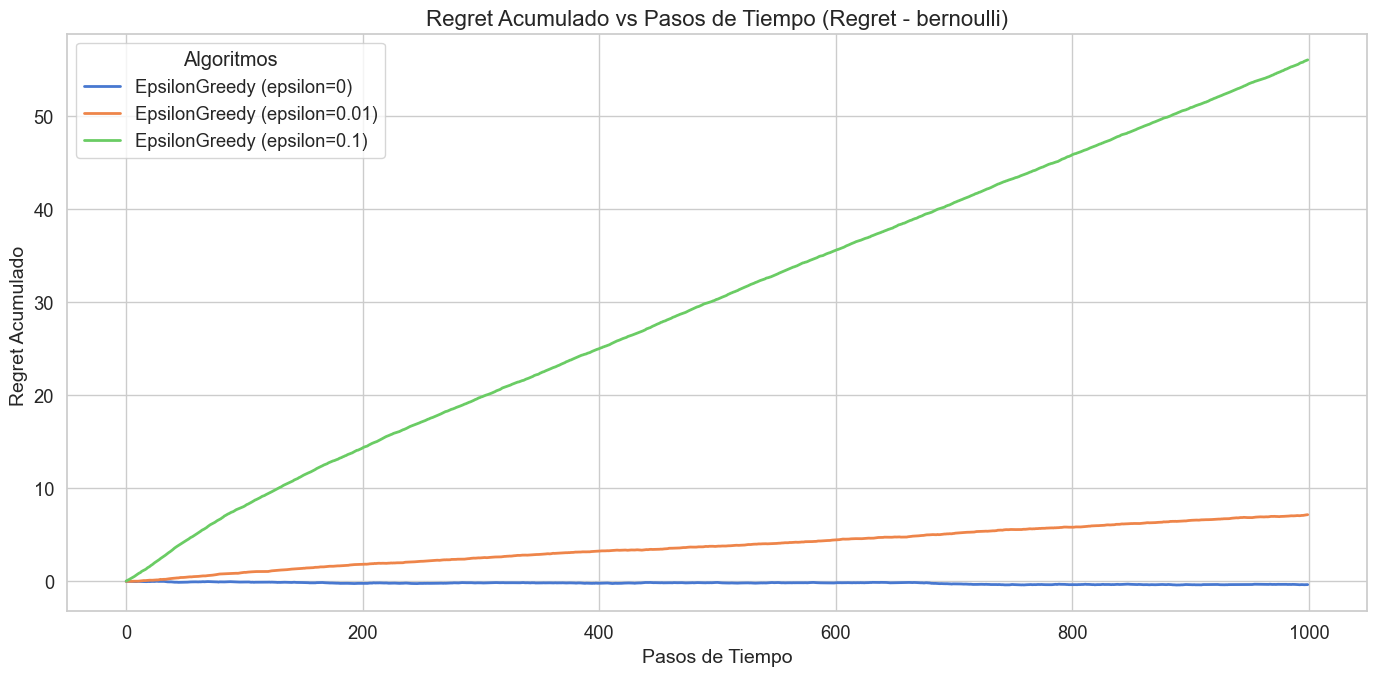

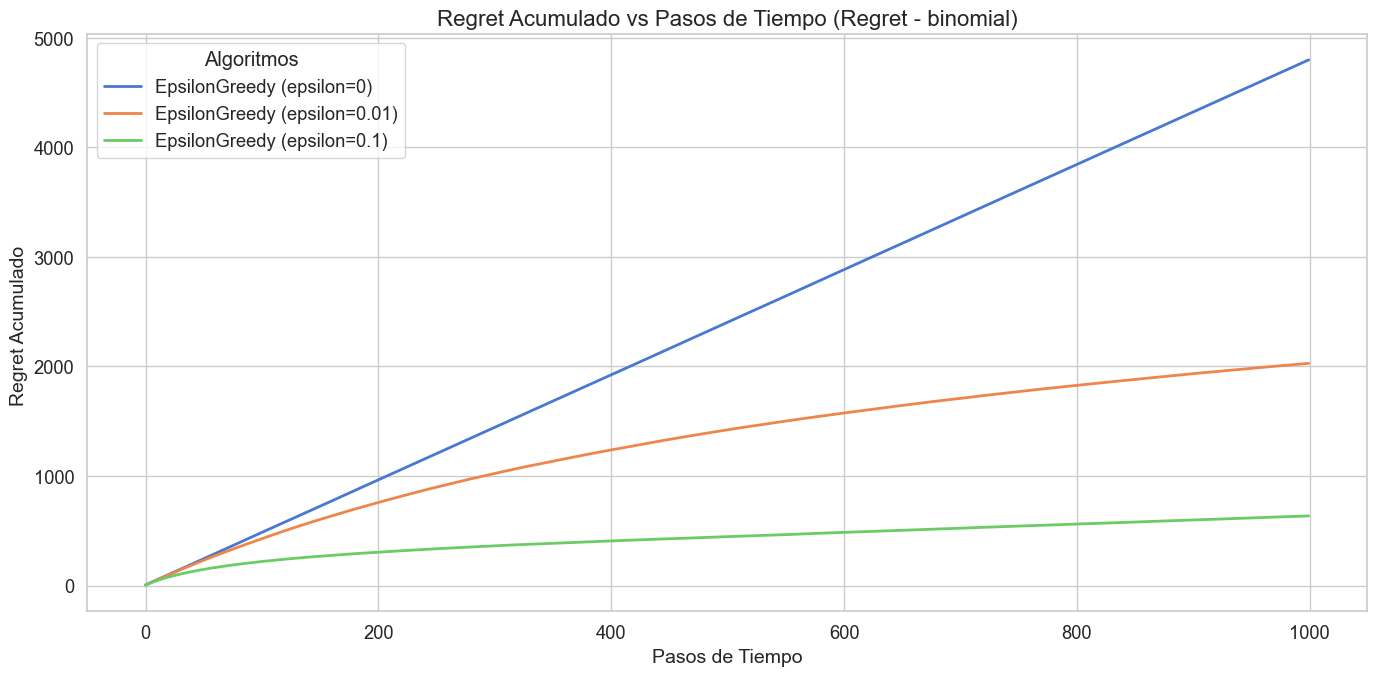

In [26]:
plot(plot_regret, steps, results, REGRET_NAME, algorithms, "Regret")

In [27]:
SELECTED_NAME = "selected" ; AVG_REWARD_NAME = "avg_reward" ; IS_OPTIMAL_NAME = "is_optimal"
def build_arm_stats(bandit, counts, avg_rewards_per_arm, algorithm_labels):
    return [{
        arm_idx: {
            SELECTED_NAME: counts[algo_idx][arm_idx],
            AVG_REWARD_NAME: avg_rewards_per_arm[algo_idx][arm_idx],
            IS_OPTIMAL_NAME: arm_idx == bandit.optimal_arm,
        } for arm_idx in range(bandit.k)
    } for algo_idx in range(len(algorithm_labels))]

In [28]:
normal_results = results[NORMAL_NAME]
bernoulli_results = results[BERNOULLI_NAME]
binomial_results = results[BINOMIAL_NAME]

arm_stats_normal = build_arm_stats(bandits[NORMAL_NAME], normal_results[COUNTS_NAME], normal_results[VALUES_NAME], algorithms)
arm_stats_bernoulli = build_arm_stats(bandits[BERNOULLI_NAME], bernoulli_results[COUNTS_NAME], bernoulli_results[VALUES_NAME], algorithms)
arm_stats_binomial = build_arm_stats(bandits[BINOMIAL_NAME], binomial_results[COUNTS_NAME], binomial_results[VALUES_NAME], algorithms)

<Figure size 1400x700 with 0 Axes>

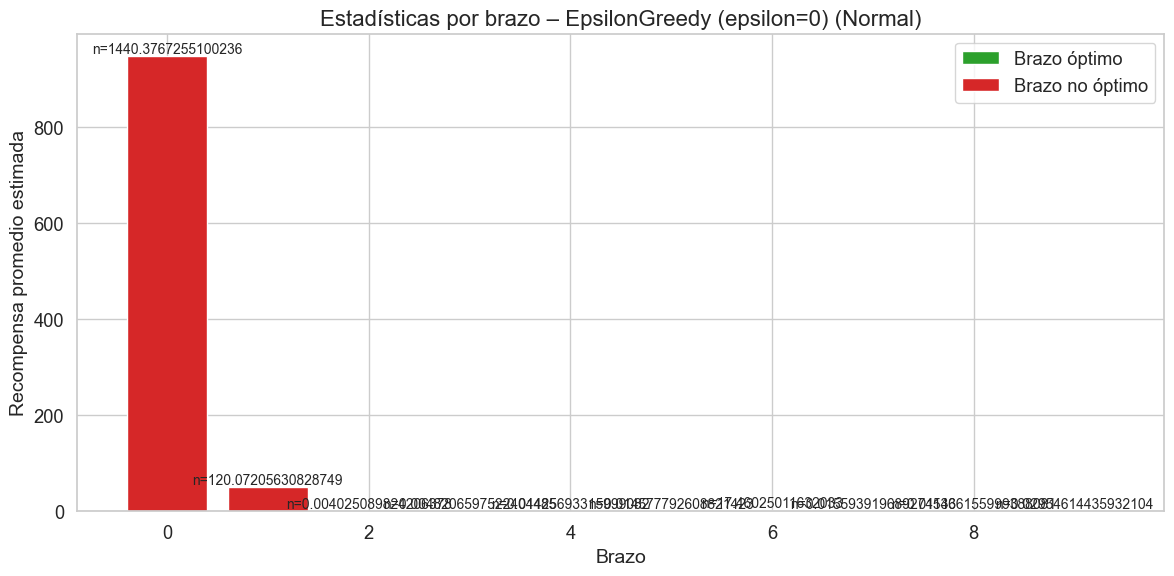

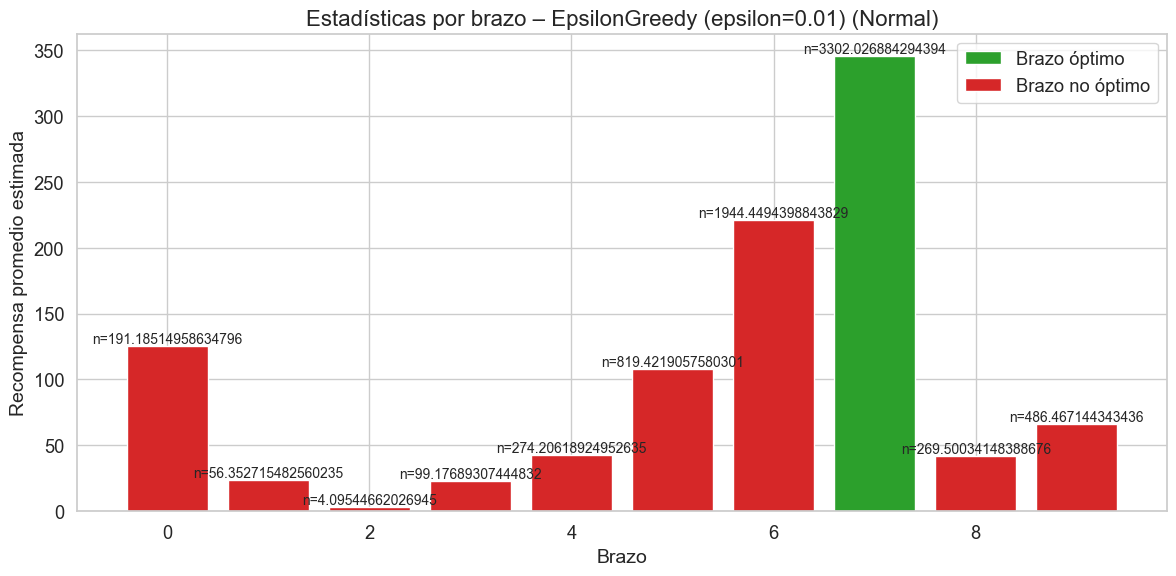

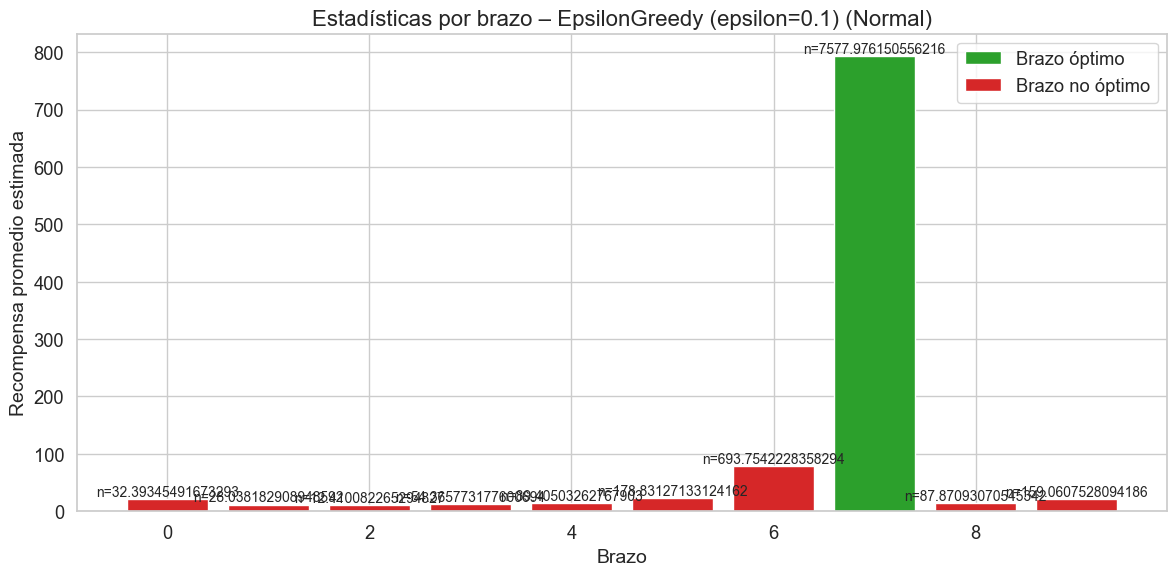

<Figure size 1400x700 with 0 Axes>

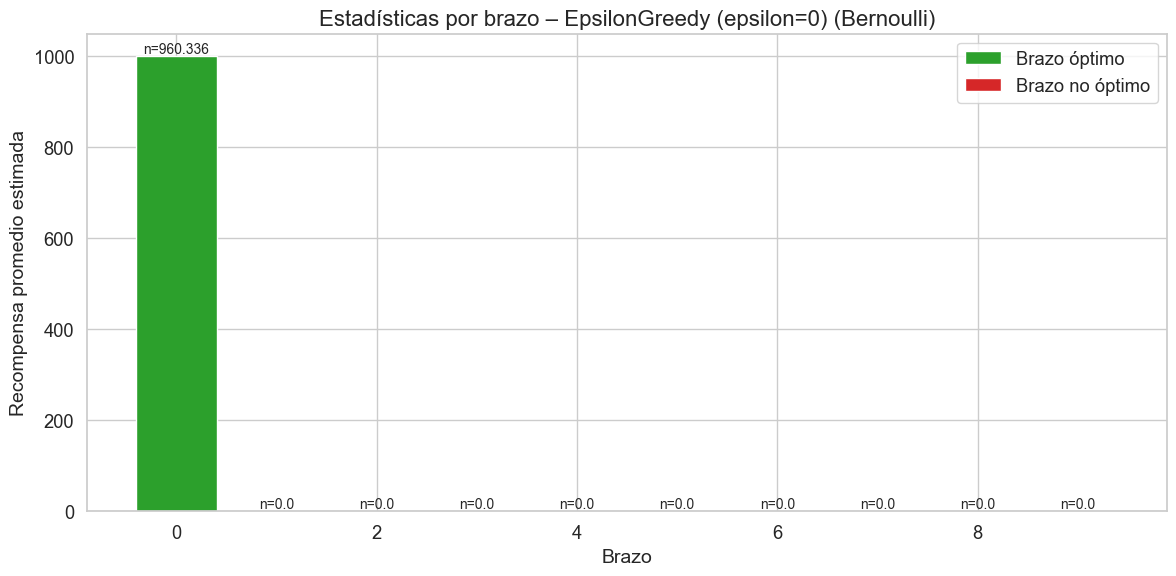

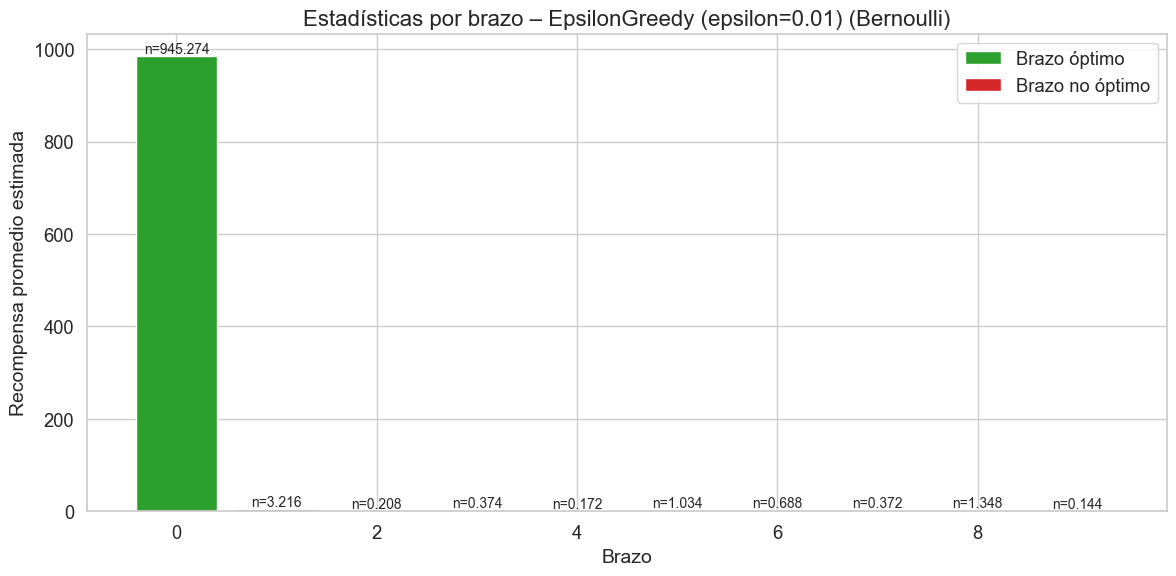

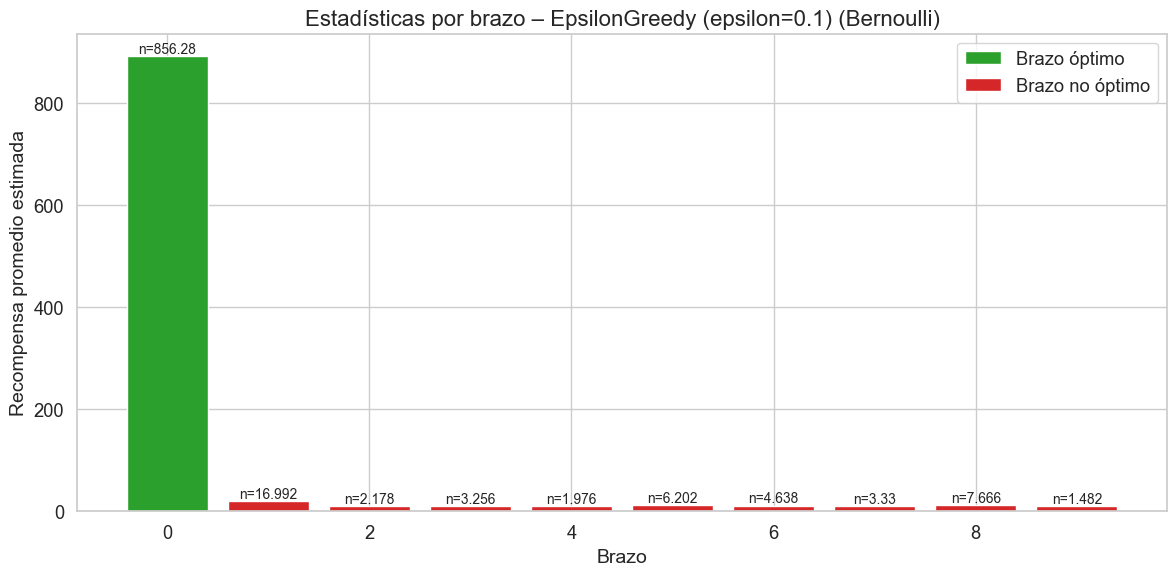

<Figure size 1400x700 with 0 Axes>

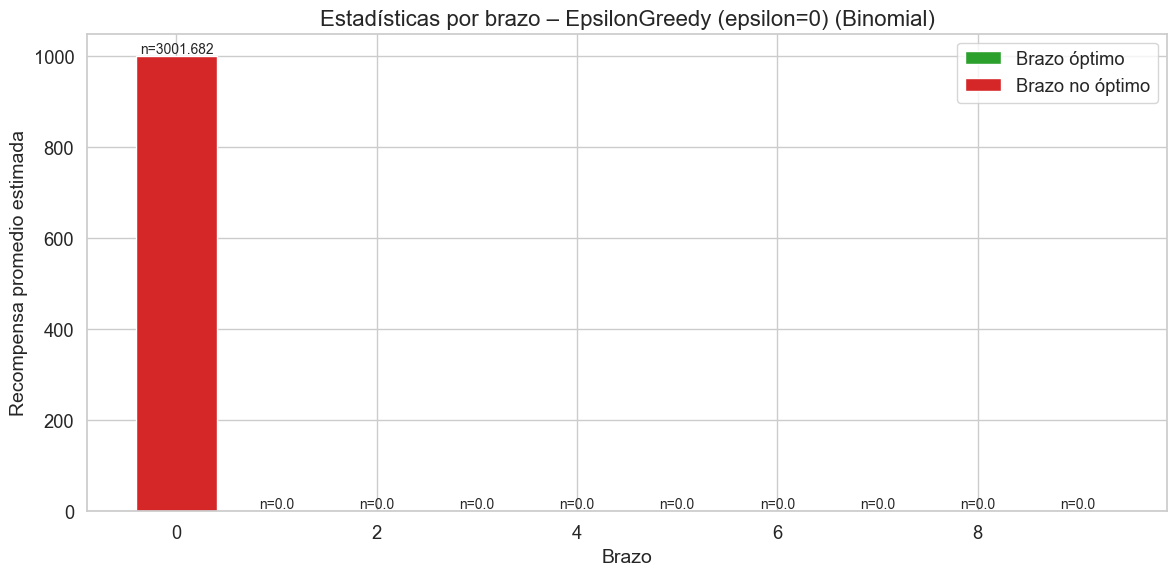

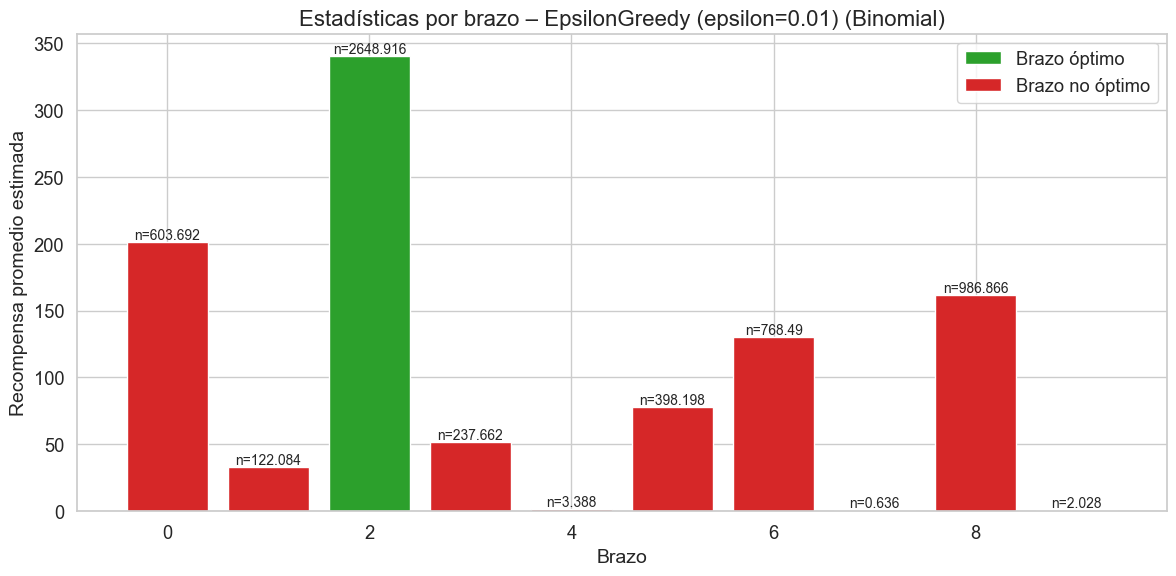

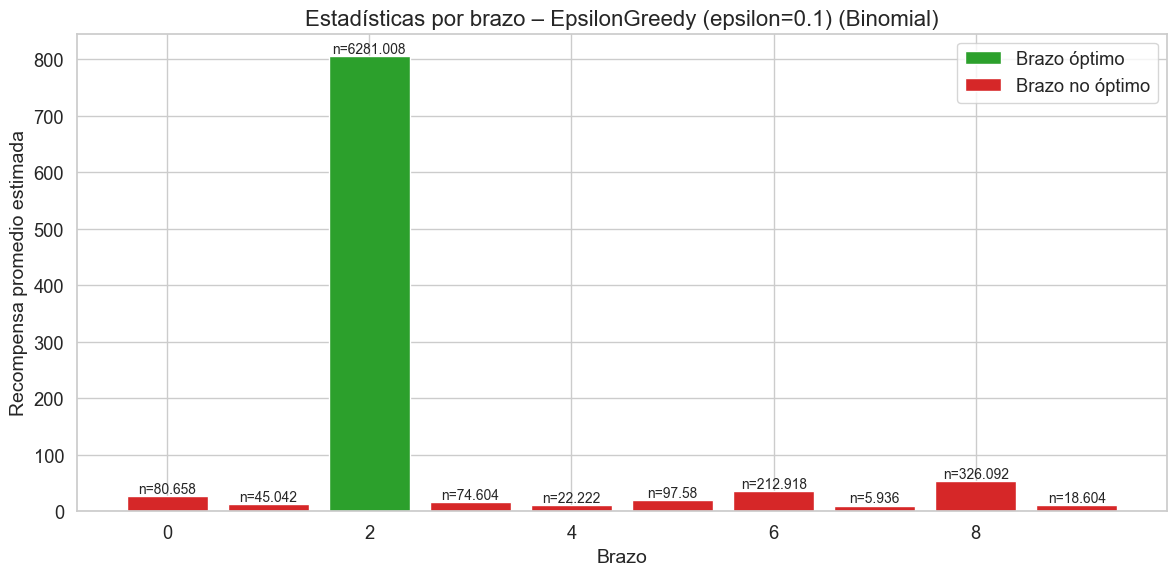

In [29]:
plot_arm_statistics(arm_stats_normal, algorithms, "Normal")
plot_arm_statistics(arm_stats_bernoulli, algorithms, "Bernoulli")
plot_arm_statistics(arm_stats_binomial, algorithms, "Binomial")